In [18]:
import pandas as pd
import missingno
import sys

sys.path.insert(0, "../Modules")

from preprocessing_utils import *

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

In [19]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'

In [20]:
dataset = pd.read_csv(f'data/{NUTS0}_{NUTS2}_WNV_Dataset_2010_2021.csv', encoding=enc)
geomorphological = pd.read_csv('data/GR_Geomorphological.csv')

In [21]:
dataset.head()

,x,y,dt_placement,nuts2,lau1,lau1_id,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case
0,24.12740,40.28807,2010-01-01,κεντρικης μακεδονιας,αθως,28,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,NaN,NaN,NaN,46.96020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.642500,15.530000,9.755000,10.633286,6.832500,8.883182,3.811746,13.083628,6.037902,16.634859,8.565833,34.075000,97.500000,0.575000,1,0,0
1,22.41314,40.63121,2010-01-01,κεντρικης μακεδονιας,αλεξανδρειας,7,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,478.8,38293.0,86.8,46.40306,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.705000,12.360000,7.050000,6.907708,4.406161,10.730556,1.957517,19.149590,4.396618,28.020071,9.308866,14.800000,40.250000,0.000000,1,0,0
2,22.07467,40.99173,2010-01-01,κεντρικης μακεδονιας,αλμωπιας,13,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,985.8,24924.0,28.0,46.55763,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.388182,9.579091,5.197273,3.313442,2.001560,3.998298,0.826676,11.100321,2.044771,19.138418,5.884069,20.218182,39.590909,0.045455,1,0,0
3,22.89198,40.65603,2010-01-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,17,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,9.8,49674.0,5319.1,46.65786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.180000,13.470000,8.890000,12.730000,5.510000,9.853333,3.612000,18.272222,6.046667,26.770000,11.750000,15.000000,39.900000,0.000000,3,0,0
4,23.97067,40.91960,2010-01-01,κεντρικης μακεδονιας,αμφιπολης,35,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,411.8,7169.0,22.3,47.42369,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.135000,12.090000,8.180000,8.143000,3.953714,10.209315,2.185636,15.249258,3.555705,20.722821,8.455035,20.225000,29.825000,0.000000,1,0,0


In [22]:
geomorphological.head()

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,21.70716,40.85356,8788.238413,3579.565342,7,218.197352,1441.734590,205.981683,0.0,1.633492
1,21.70716,40.85805,9126.184686,3102.782829,25,148.490395,1414.573604,208.019704,0.0,5.978065
2,21.70716,40.86255,9444.375988,2615.821241,12,268.821029,1382.931273,214.040118,0.0,7.308688
3,21.70716,40.86704,9777.368921,2134.973315,14,234.716824,1350.239574,217.167885,0.0,8.341557
4,21.71308,40.84458,7746.478563,4537.247524,10,212.312775,1469.198207,197.436593,0.0,1.937643


In [23]:
distances, indicies = calculate_nearest_topological(dataset, geomorphological)

In [24]:
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.04975425933542595
Max distance: 10.347618535160215


In [25]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

In [26]:
for index in indicies:
    df_geo = df_geo.append(geomorphological.iloc[[index]])

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

In [27]:
dataset = pd.concat([dataset, df_geo], axis=1, join = 'outer')

In [28]:
dataset.head()

,x,y,dt_placement,nuts2,lau1,lau1_id,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,24.12740,40.28807,2010-01-01,κεντρικης μακεδονιας,αθως,28,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,NaN,NaN,NaN,46.96020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.642500,15.530000,9.755000,10.633286,6.832500,8.883182,3.811746,13.083628,6.037902,16.634859,8.565833,34.075000,97.500000,0.575000,1,0,0,741.395353,5480.994362,0,229.615930,142.067691,199.028237,134451.168165,1.385666
1,22.41314,40.63121,2010-01-01,κεντρικης μακεδονιας,αλεξανδρειας,7,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,478.8,38293.0,86.8,46.40306,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.705000,12.360000,7.050000,6.907708,4.406161,10.730556,1.957517,19.149590,4.396618,28.020071,9.308866,14.800000,40.250000,0.000000,1,0,0,19302.853155,218.518170,4,165.845298,4.439405,180.217997,0.000000,252.542758
2,22.07467,40.99173,2010-01-01,κεντρικης μακεδονιας,αλμωπιας,13,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,985.8,24924.0,28.0,46.55763,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.388182,9.579091,5.197273,3.313442,2.001560,3.998298,0.826676,11.100321,2.044771,19.138418,5.884069,20.218182,39.590909,0.045455,1,0,0,23100.611480,687.499343,0,127.752566,125.810202,179.704207,0.000000,1.162002
3,22.89198,40.65603,2010-01-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,17,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,9.8,49674.0,5319.1,46.65786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.180000,13.470000,8.890000,12.730000,5.510000,9.853333,3.612000,18.272222,6.046667,26.770000,11.750000,15.000000,39.900000,0.000000,3,0,0,783.725557,1072.158690,3,157.852939,3.721570,180.299131,0.000000,56.126569
4,23.97067,40.91960,2010-01-01,κεντρικης μακεδονιας,αμφιπολης,35,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,411.8,7169.0,22.3,47.42369,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.135000,12.090000,8.180000,8.143000,3.953714,10.209315,2.185636,15.249258,3.555705,20.722821,8.455035,20.225000,29.825000,0.000000,1,0,0,16692.000632,304.097354,4,255.084988,347.388991,187.472171,0.000000,20.820754


<AxesSubplot:>

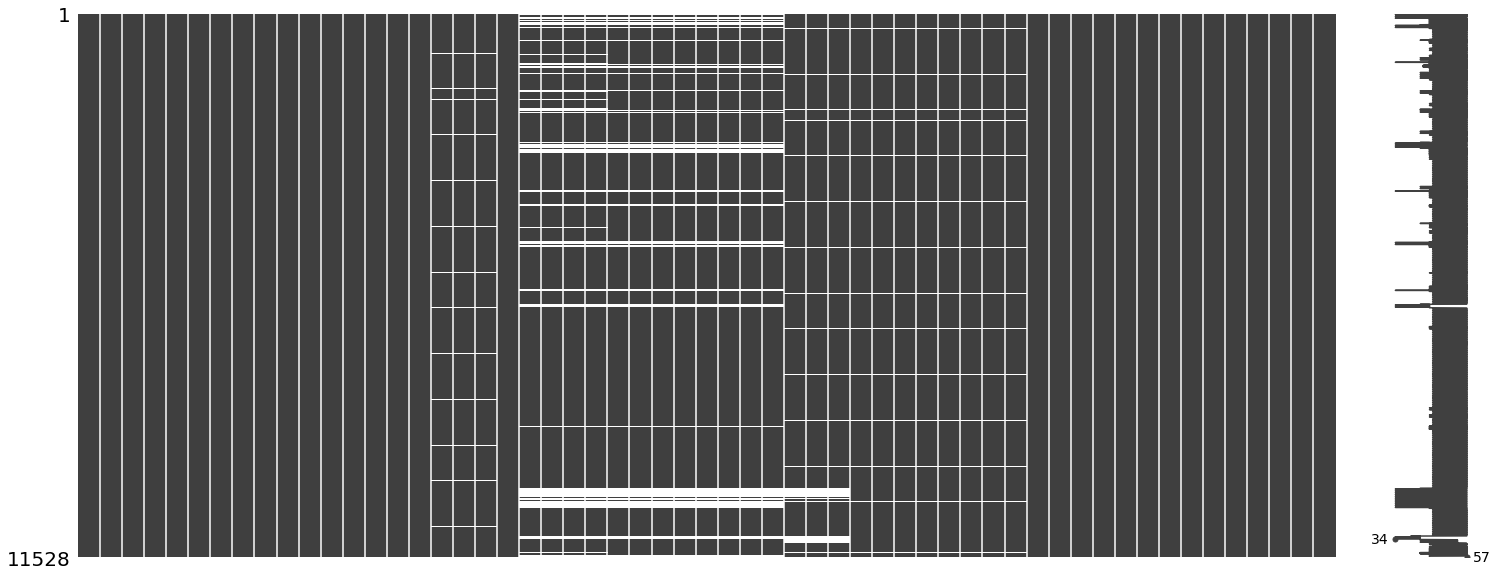

In [29]:
missingno.matrix(dataset)

In [30]:
cols = dataset.columns

In [31]:
rearranged = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'lau1_id', 'day', 'month',
       'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos',
       'week_sin', 'week_cos', 'area', 'population', 'population_density',
       'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean',
       'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std',
       'ndbi_std', 'lst', 'lst_day', 'lst_night', 'lst_jan_day_mean',
       'lst_jan_night_mean', 'lst_feb_day_mean', 'lst_feb_night_mean',
       'lst_mar_day_mean', 'lst_mar_night_mean', 'lst_apr_day_mean',
       'lst_apr_night_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km',
       'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km',
       'fs_area_1km', 'flow_accu_200m', 'mosq_pred', 'mosq_previous', 'case']

In [32]:
dataset = dataset[rearranged]

In [33]:
dataset.to_csv(f"data/{NUTS0}_{NUTS2}_WNV_Dataset_2010_2021.csv", encoding = enc, index = False)